# ElasticNet Regression

**Owner: Samith | Review 1 - Regression Track**

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

SEED = 42
sns.set_theme(style="whitegrid", palette="colorblind")

data_path = next(
    (parent / "data" / "health_insurance.csv" for parent in (Path.cwd(), *Path.cwd().parents)
     if (parent / "data" / "health_insurance.csv").exists()),
    None,
)
if data_path is None:
    raise FileNotFoundError("Run this notebook from inside the ML-301 repository.")

raw_df = pd.read_csv(data_path)
duplicate_count = int(raw_df.duplicated().sum())
df = raw_df.drop_duplicates().copy()
X = df.drop(columns="claim")
y = df["claim"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

X_train = X_train.copy()
X_test = X_test.copy()

# Age and BMI can interact in their effect on insurance cost.
for frame in (X_train, X_test):
    frame["age_bmi_interaction"] = frame["age"] * frame["bmi"]
numeric_features.append("age_bmi_interaction")

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
    ]), categorical_features),
])

print(f"Removed {duplicate_count:,} exact duplicates.")
print(f"Training rows: {len(X_train):,}; test rows: {len(X_test):,}")

Removed 1,096 exact duplicates.
Training rows: 11,123; test rows: 2,781


In [2]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV

model_name = "ElasticNet Regression"
search = GridSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", ElasticNet(max_iter=20_000)),
    ]),
    {
        "regressor__alpha": [0.1, 1.0, 10.0],
        "regressor__l1_ratio": [0.2, 0.5, 0.8],
    },
    scoring="r2",
    cv=5,
    n_jobs=-1,
)
search.fit(X_train, y_train)
model = search.best_estimator_
cv_results = pd.DataFrame(search.cv_results_)
default_score = cv_results.loc[
    (cv_results["param_regressor__alpha"] == 1.0)
    & (cv_results["param_regressor__l1_ratio"] == 0.5),
    "mean_test_score",
].iloc[0]
print("Best parameters:", search.best_params_)
print("Best 5-fold CV R2:", round(search.best_score_, 4))
print("Improvement over defaults:", round(search.best_score_ - default_score, 4))

Best parameters: {'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.8}
Best 5-fold CV R2: 0.7521
Improvement over defaults: 0.3559


,R2,RMSE,MAE
ElasticNet Regression,0.756,6040.768,4150.476


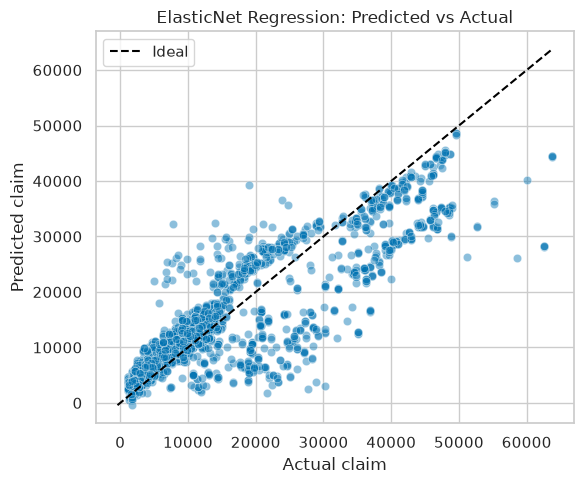

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)
metrics = pd.DataFrame({
    "R2": [r2_score(y_test, y_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred))],
    "MAE": [mean_absolute_error(y_test, y_pred)],
}, index=[model_name])
display(metrics.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.45, ax=ax)
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(limits, limits, "--", color="black", label="Ideal")
ax.set(title=f"{model_name}: Predicted vs Actual", xlabel="Actual claim", ylabel="Predicted claim")
ax.legend()
plt.tight_layout()
plt.show()

assert np.isfinite(metrics.to_numpy()).all()

### Interpretation

The model uses the same deduplicated records, fixed 80:20 split, train-only imputation, robust scaling, encoding, and engineered feature as every other regression notebook. This makes the final metric comparison fair.

ElasticNet combines L1 and L2 penalties; cross-validation selects both alpha and the L1 ratio.